# LinearSVC com metadados morfossintáticos (spaCy) + TF-IDF

**Pergunta:** metadados morfossintáticos extraídos por notícia com spaCy melhoram o `LinearSVC`, sozinhos ou junto com o TF-IDF `word+char`, dentro do Fake.br e fora dele (FakeRecogna)?

O foco é o modelo **M2 = word+char + meta_spacy**. Diferente dos metadados do corpus (etiquetador NILC), o bloco spaCy pode ser calculado para qualquer texto, inclusive notícias novas no app e o FakeRecogna. B0 entra só como referência pareada, e S1 (só spaCy) mostra o sinal isolado.

Perguntas derivadas:
1. Com algum C e peso `w` do bloco, M2 supera B0 de forma consistente nos 5 folds?
2. O peso do bloco denso frente ao TF-IDF importa? `w` alto deixa o bloco dominar a margem, e `w` baixo o apaga.
3. Algum ganho se mantém fora do domínio?

**Protocolo (decisões do time):**
- `X_te`/`y_te` só no fim, uma única vez. Toda escolha (config, C, peso do bloco, k) é feita na CV sobre `X_tr`.
- `StratifiedKFold(5, shuffle=True, random_state=42)`, os mesmos folds dos notebooks 05–09.
- Comparação **pareada por fold** contra a base B0 (word+char, C=1): `delta_cv`, desvio das diferenças e `folds_melhores`. Δ < ~0,01 sem 5/5 folds melhores é **empate**.
- `return_train_score`: gap treino − CV como diagnóstico (gap baixo com F1 baixo é underfitting).
- Vetorizadores, imputer, scaler e χ² ajustados **dentro de cada fold**. A extração spaCy é por documento e sem `fit`, então é pré-calculada uma vez.
- `LinearSVC(class_weight="balanced")`, como nos notebooks 03 e 05–09, com o solver primal (`dual=False`): o problema é estritamente convexo, então o ótimo é o mesmo, e a reprodução exata do B0 na seção 5 confirma isso. O dataset é 2880/2880, então o `class_weight` não entra na busca.

| ID | Blocos |
|---|---|
| B0 | word+char (base, referência) |
| M2 | word+char + meta_spacy |
| S1 | só meta_spacy (sinal isolado) |

In [1]:
import os
import re
import time
import glob
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.svm import LinearSVC
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

import metadados_spacy as ms

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

X_tr, X_te, y_tr, y_te = joblib.load("../../data/dados_preparados.pkl")
configs = joblib.load("../../data/transformers.pkl")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# dual=False (primal): mesmo ótimo do problema convexo, mas converge 5–20x mais rápido com o bloco meta denso.
# Com o dual padrão, C=10 e w=3 levavam ~110 s/fold e não convergiam em 20 mil iterações.
SVC_BASE = LinearSVC(class_weight="balanced", random_state=42, max_iter=20000, dual=False)

print(f"Treino: {len(X_tr):,} | Teste (isolado): {len(X_te):,}")

Treino: 5,760 | Teste (isolado): 1,440


## 1. Texto completo do corpus (só para o diagnóstico de artefato)

**Pergunta:** o `dados_preparados.pkl` guarda só o texto truncado. Para checar o artefato de fonte no texto **bruto** (seção 3), recarregamos o corpus com o mesmo código do `01_Data_Prep` e conferimos que o índice bate com `X_tr`/`X_te`. Nada daqui entra no modelo.

In [2]:
def carregar_textos(pasta, label):
    registros = []
    for caminho in sorted(glob.glob(os.path.join(pasta, "*.txt"))):
        id_noticia = os.path.basename(caminho).replace(".txt", "t" if label == 0 else "")
        with open(caminho, encoding="utf-8") as f:
            registros.append({"id": id_noticia, "texto": f.read(), "label": label})
    return pd.DataFrame(registros)

def normalizar(texto):
    # Idêntica ao 01_Data_Prep (também usada no FakeRecogna, seção 9)
    texto = str(texto)
    texto = texto.translate(str.maketrans({"\x96": "-", "\x97": "-", "\x93": '"', "\x94": '"', "\x91": "'", "\x92": "'"}))
    texto = re.sub(r"[\x80-\x9f]", " ", texto)
    texto = re.sub(r"[–—]", "-", texto)
    texto = re.sub(r"[“”«»]", '"', texto)
    texto = re.sub(r"[‘’]", "'", texto)
    texto = re.sub(r"\s*(?:\[\.*\]|\.{2,}|…)", ".", texto)
    texto = re.sub(r"\d", "0", texto)
    return " ".join(texto.split())

def truncar(texto, n=100):
    return " ".join(str(texto).split()[:n])

base = "../../data/Fake.br-Corpus-master/full_texts"
df = pd.concat([carregar_textos(f"{base}/fake", 1), carregar_textos(f"{base}/true", 0)], ignore_index=True)

trunc = df["texto"].map(normalizar).map(truncar)
assert (trunc.loc[X_tr.index] == X_tr["texto_trunc"]).all() and (trunc.loc[X_te.index] == X_te["texto_trunc"]).all()
assert (df.loc[X_tr.index, "label"] == y_tr).all() and (df.loc[X_te.index, "label"] == y_te).all()
print("Índices alinhados com o corpus: OK")

Índices alinhados com o corpus: OK


## 2. Extração spaCy por notícia

**Pergunta:** quais taxas morfossintáticas cada notícia tem, calculadas sobre o **mesmo** `texto_trunc` que o TF-IDF vê?

O `metadados_spacy.py` roda o `pt_core_news_sm` (`nlp.pipe`, `batch_size=64`, `ner` desabilitado) e devolve só **taxas**:
- POS por token: ADJ, ADP, ADV, AUX, CCONJ, DET, NOUN, NUM, PRON, PROPN, PUNCT, SCONJ, VERB.
- DEP por token: nsubj, obj, obl, nmod, case, advmod, amod, ccomp, xcomp, mark.
- Sentença: sentenças/token e palavras por sentença.
- Morfologia: verbos (VERB+AUX) com `Mood=Imp` e `Mood=Sub` sobre o total de verbos (NaN sem verbos, imputado no pipeline), e tokens com `Person=1|2` por token.
- Diagnóstico, sem entrar no modelo: POS SPACE/X/SYM/INTJ e DEP `dep`.

O resultado é cacheado em `metadados_spacy.parquet` (gitignored), indexado como `X_tr`/`X_te`.

In [3]:
CACHE = Path("../../data/metadados_spacy.parquet")
textos = pd.concat([X_tr["texto_trunc"], X_te["texto_trunc"]])

if CACHE.exists():
    feats = pd.read_parquet(CACHE)
    print(f"Cache carregado: {CACHE}")
else:
    t0 = time.time()
    feats = ms.extrair(textos, batch_size=64)
    feats.to_parquet(CACHE)
    print(f"Extração de {len(feats):,} notícias em {time.time() - t0:.0f}s")

assert feats.index.equals(textos.index)
feats_tr, feats_te = feats.loc[X_tr.index], feats.loc[X_te.index]
print(feats.shape)
feats_tr.join(y_tr).groupby("label").mean().T.round(4)

Cache carregado: metadados_spacy.parquet
(7200, 34)


label,0,1
n_tokens,113.8694,110.7677
pos_ADJ,0.0431,0.0420
pos_ADP,0.1787,0.1451
pos_ADV,0.0240,0.0323
pos_AUX,0.0217,0.0300
pos_CCONJ,0.0235,0.0214
pos_DET,0.0723,0.0905
pos_NOUN,0.2071,0.1872
pos_NUM,0.0283,0.0263
pos_PRON,0.0245,0.0291


**Conclusão:** uma linha de taxas por notícia, já alinhada ao split. Na seção 3 vemos quais delas carregam sinal e quais são redundantes ou artefato.

## 3. Artefato de fonte: `SPACE` e `dep` ainda diferem depois da normalização?

**Pergunta:** a `fix-metadados` achou POS `SPACE` 2,88% (fake) × 0,29% (real) e DEP `dep` 3,21% × 0,64% no texto **bruto e completo**, agregado por classe. Isso sobrevive à `normalizar()` + truncamento?

Comparamos as duas situações no treino:
- texto bruto e completo, numa amostra estratificada de 300 notícias por classe, para reproduzir o achado;
- `texto_trunc`, em todas as notícias de treino.

In [4]:
amostra = pd.concat([g.sample(300, random_state=42) for _, g in y_tr.groupby(y_tr)]).index
diag_bruto = ms.extrair(df.loc[amostra, "texto"], batch_size=16)
diag_cols = [c for c in feats.columns if c.startswith("diag_")]

tab = pd.DataFrame({
    "bruto_fake_%": diag_bruto.loc[y_tr.loc[amostra] == 1, diag_cols].mean() * 100,
    "bruto_real_%": diag_bruto.loc[y_tr.loc[amostra] == 0, diag_cols].mean() * 100,
    "trunc_fake_%": feats_tr.loc[y_tr == 1, diag_cols].mean() * 100,
    "trunc_real_%": feats_tr.loc[y_tr == 0, diag_cols].mean() * 100,
})
tab["razao_bruto"] = tab["bruto_fake_%"] / tab["bruto_real_%"]
tab["razao_trunc"] = tab["trunc_fake_%"] / tab["trunc_real_%"]
tab.round(3)

,bruto_fake_%,bruto_real_%,trunc_fake_%,trunc_real_%,razao_bruto,razao_trunc
diag_pos_SPACE,2.925,0.383,0.000,0.000,7.634,NaN
diag_pos_X,0.011,0.007,0.008,0.005,1.634,1.388
diag_pos_SYM,0.176,0.244,0.201,0.217,0.722,0.928
diag_pos_INTJ,0.016,0.006,0.016,0.002,2.808,7.409
diag_dep_dep,3.208,0.726,0.403,0.413,4.419,0.975


**Conclusão:** o artefato de fonte existe no texto bruto e some com a normalização.
- No texto bruto, `SPACE` é 2,93% (fake) contra 0,38% (real), e `dep` é 3,21% contra 0,73%. Isso reproduz a `fix-metadados`: o parser rotula como `SPACE`/`dep` as quebras de linha e os espaços múltiplos de cada site.
- Depois da `normalizar()` + truncamento, `SPACE` vai a **0** nas duas classes e `dep` fica em 0,40% contra 0,41% (razão 0,98). Não há vazamento residual de fonte por esse caminho.
- `INTJ` ainda tem razão alta (0,016% contra 0,002%), mas em frequência desprezível. Nenhuma coluna de diagnóstico entra no modelo, como previsto no desenho.

## 4. Sanity check das features spaCy: sinal, constância e redundância

**Pergunta:** quais features têm sinal entre as classes e quais são quase constantes ou redundantes (|r| > 0,9)?

- **Sinal:** d de Cohen (fake − real) no treino. Os boxplots das 10 maiores em módulo são só descritivos e não usados para selecionar.
- **Quase constante:** mais de 99% dos valores iguais à moda. Não tem informação e é removida.
- **Redundância:** para pares com |r| > 0,9, removemos a feature com maior |r| médio contra as demais. A regra **não usa o rótulo**, então não há seleção supervisionada fora da CV. Também reportamos o VIF, pela diagonal da inversa da matriz de correlação.

In [5]:
cand = ms.colunas_features(feats_tr)
F = feats_tr[cand]

def cohen_d(x, y):
    a, b = x[y == 1].dropna(), x[y == 0].dropna()
    sp_ = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / sp_

sinal = pd.DataFrame({
    "media_fake": F[y_tr == 1].mean(),
    "media_real": F[y_tr == 0].mean(),
    "cohen_d": F.apply(lambda c: cohen_d(c, y_tr)),
    "pct_moda": F.apply(lambda c: c.value_counts(normalize=True, dropna=False).iloc[0]),
    "pct_nan": F.isna().mean(),
}).sort_values("cohen_d", key=abs, ascending=False)
sinal.round(4)

/tmp/ipykernel_23831/186969705.py:7: RuntimeWarning: invalid value encountered in scalar divide
  return (a.mean() - b.mean()) / sp_


,media_fake,media_real,cohen_d,pct_moda,pct_nan
taxa_sentencas,0.0721,0.0512,1.0978,0.0227,0.0
tam_medio_sentenca_sp,13.0230,18.6683,-1.0170,0.0984,0.0
pos_ADP,0.1451,0.1787,-0.9317,0.0155,0.0
dep_case,0.1417,0.1748,-0.9252,0.0158,0.0
dep_nmod,0.0823,0.1061,-0.7323,0.0111,0.0
pos_DET,0.0905,0.0723,0.6919,0.0120,0.0
pos_NOUN,0.1872,0.2071,-0.5485,0.0177,0.0
pos_VERB,0.1136,0.0986,0.5253,0.0144,0.0
pos_AUX,0.0300,0.0217,0.5242,0.0724,0.0
dep_nsubj,0.0647,0.0550,0.5052,0.0165,0.0


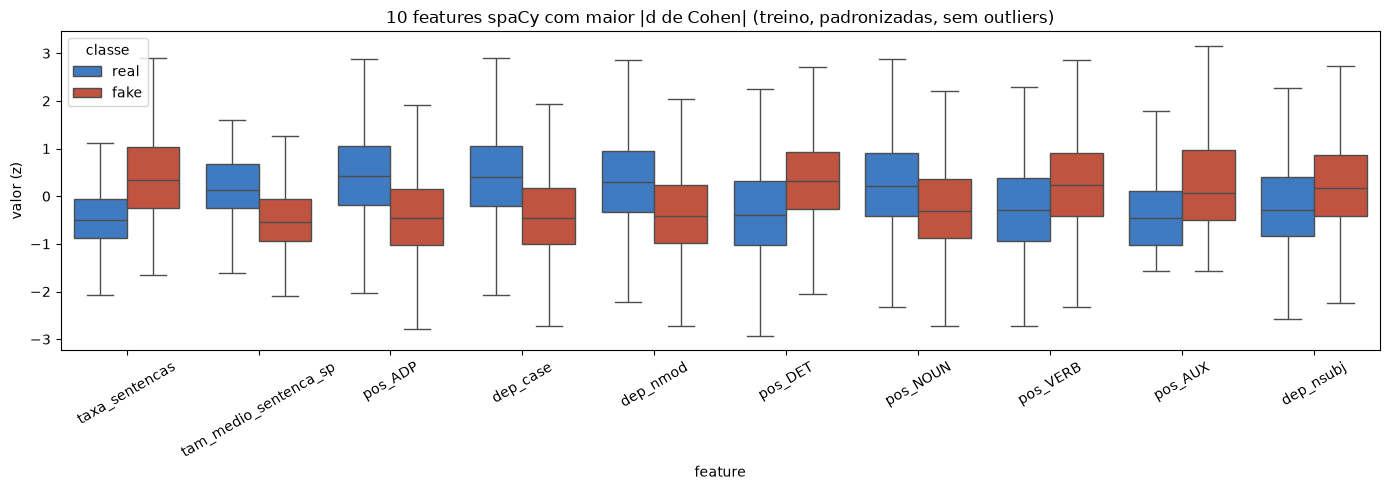

In [6]:
top10 = sinal.index[:10]
long = F[top10].apply(lambda c: (c - c.mean()) / c.std()).join(y_tr.map({0: "real", 1: "fake"}).rename("classe"))
long = long.melt(id_vars="classe", var_name="feature", value_name="valor (z)")
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=long, x="feature", y="valor (z)", hue="classe", showfliers=False, ax=ax,
            palette={"fake": "#d6452a", "real": "#2a78d6"})
ax.set_title("10 features spaCy com maior |d de Cohen| (treino, padronizadas, sem outliers)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

Quase constantes (removidas): ['verbo_imperativo']
Redundantes (removida, par mantido, |r|): [('dep_case', 'pos_ADP', np.float64(0.983)), ('pos_ADV', 'dep_advmod', np.float64(0.948)), ('pos_SCONJ', 'dep_mark', np.float64(0.945))]

meta_spacy final (24): ['pos_ADJ', 'pos_ADP', 'pos_AUX', 'pos_CCONJ', 'pos_DET', 'pos_NOUN', 'pos_NUM', 'pos_PRON', 'pos_PROPN', 'pos_PUNCT', 'pos_VERB', 'dep_nsubj', 'dep_obj', 'dep_obl', 'dep_nmod', 'dep_advmod', 'dep_amod', 'dep_ccomp', 'dep_xcomp', 'dep_mark', 'taxa_sentencas', 'tam_medio_sentenca_sp', 'verbo_subjuntivo', 'pessoa_1_2']

VIF > 5:
pos_PROPN     36.3
pos_ADP       23.4
pos_NOUN      16.5
pos_VERB      12.6
pos_PUNCT     11.3
pos_ADJ       10.8
pos_DET        9.8
pos_NUM        8.1
dep_nmod       6.4
pos_PRON       5.7
dep_amod       5.3
dep_advmod     5.1
dtype: float64


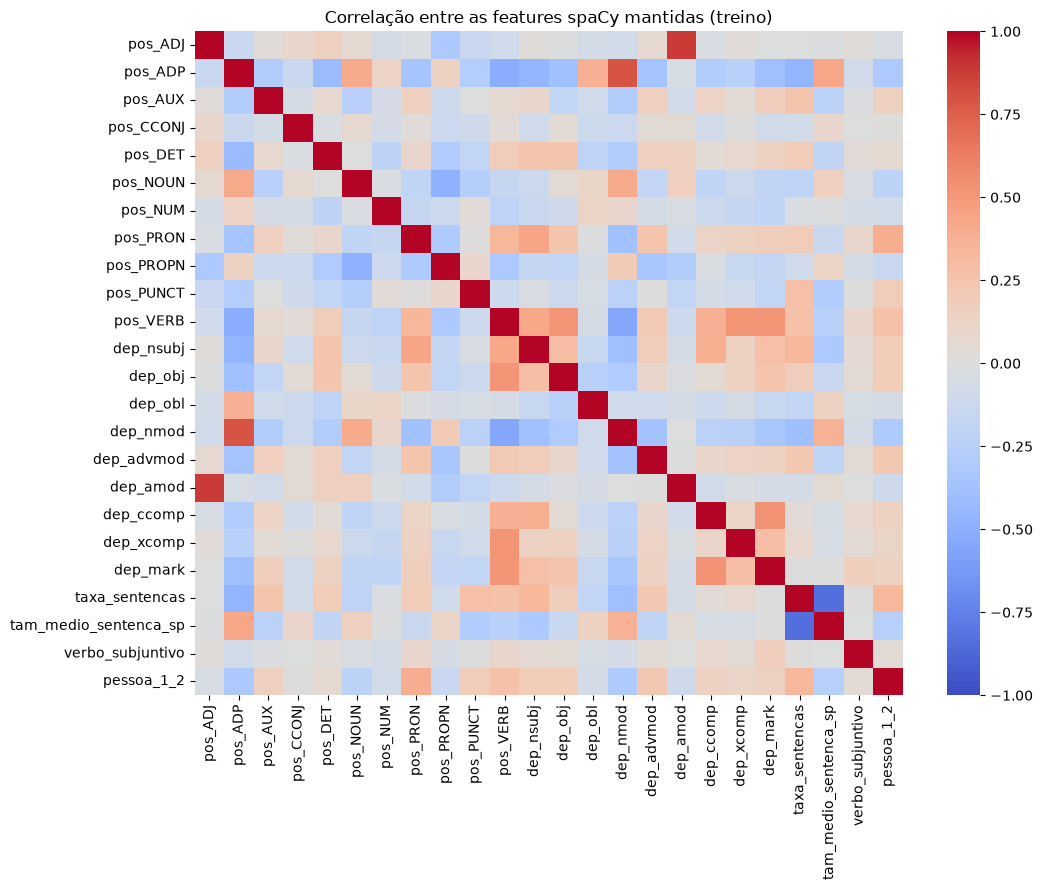

In [7]:
constantes = sinal.index[sinal["pct_moda"] > 0.99].tolist()
restantes = [c for c in cand if c not in constantes]

corr = F[restantes].corr()
removidas = []
while True:
    c = corr.loc[restantes, restantes].abs().to_numpy(copy=True)
    np.fill_diagonal(c, 0)
    if c.max() <= 0.9:
        break
    i, j = np.unravel_index(c.argmax(), c.shape)
    sai = restantes[i] if c[i].mean() >= c[j].mean() else restantes[j]
    fica = restantes[j] if sai == restantes[i] else restantes[i]
    removidas.append((sai, fica, round(c.max(), 3)))
    restantes.remove(sai)

META_SPACY = restantes
vif = pd.Series(np.diag(np.linalg.inv(F[META_SPACY].fillna(F[META_SPACY].median()).corr().values)), index=META_SPACY)

print("Quase constantes (removidas):", constantes)
print("Redundantes (removida, par mantido, |r|):", removidas)
print(f"\nmeta_spacy final ({len(META_SPACY)}): {META_SPACY}")
print("\nVIF > 5:")
print(vif[vif > 5].sort_values(ascending=False).round(1))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(F[META_SPACY].corr(), cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlação entre as features spaCy mantidas (treino)")
plt.tight_layout()
plt.show()

**Conclusão:**
- **Removidas:**
  - `verbo_imperativo` é constante, porque o `pt_core_news_sm` não marcou nenhum imperativo;
  - 3 redundâncias por |r| > 0,9: `dep_case`~`pos_ADP` (0,98), `pos_ADV`~`dep_advmod` (0,95) e `pos_SCONJ`~`dep_mark` (0,95).
- **meta_spacy final:** 24 features.
- **Maiores |d de Cohen| (treino):**
  - **fake:** mais sentenças por token (d = +1,10, ou seja, sentenças mais curtas: 13,0 contra 18,7 palavras), mais DET, VERB, AUX, `nsubj`, `advmod` e 1ª/2ª pessoa;
  - **real:** mais ADP/`case` (d ≈ −0,93), `nmod` (−0,73) e NOUN, ou seja, frases nominais longas e preposicionadas, típicas de texto jornalístico.
  - É o mesmo sentido da `fix-metadados`, agora por notícia e no texto truncado.
- **VIF:** fica alto nas taxas POS (PROPN 36, ADP 23, NOUN 17), porque as taxas POS somam ~1 e são composicionais. Com L2 isso não atrapalha a predição, mas os coeficientes individuais devem ser lidos com cautela.

## 5. Motor de CV por blocos

**Pergunta:** como avaliar 35 combinações (config × C × peso) em 5 folds sem reajustar o TF-IDF a cada uma e sem vazamento?

Em cada fold, ajustamos **uma vez** no treino do fold:
- o `ColumnTransformer(word+char)` do `transformers.pkl`;
- um `SimpleImputer(median) + StandardScaler` no bloco meta_spacy.

Depois, só transformamos a validação do fold. Cada candidato empilha os blocos com o bloco meta multiplicado por `w`. É exatamente o que o `ColumnTransformer(..., transformer_weights={"meta": w})` faz, porque os pesos multiplicam a saída de cada transformer antes do `hstack`. A seção 7 confere essa equivalência com o pipeline real do scikit-learn.

`fit_time_s` = tempo de ajuste dos blocos usados no fold + tempo de ajuste do `LinearSVC`, em média nos folds. É comparável ao `mean_fit_time` do scikit-learn.

In [8]:
X_tr_full = X_tr.join(feats_tr[META_SPACY])
X_te_full = X_te.join(feats_te[META_SPACY])

BLOCOS_META = {"spacy": META_SPACY}
def meta_pipe():
    return Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])

folds = []
for i, (tr, va) in enumerate(cv.split(X_tr_full, y_tr)):
    Xa, Xb = X_tr_full.iloc[tr], X_tr_full.iloc[va]
    f = {"tr": tr, "va": va, "y_tr": y_tr.iloc[tr].values, "y_va": y_tr.iloc[va].values, "t": {}}
    t0 = time.time()
    ct = ColumnTransformer(configs["word+char"]).fit(Xa)
    f["txt"] = (ct.transform(Xa).tocsr(), ct.transform(Xb).tocsr())
    f["t"]["txt"] = time.time() - t0
    for nome, cols in BLOCOS_META.items():
        t0 = time.time()
        mp = meta_pipe().fit(Xa[cols])
        f[nome] = (mp.transform(Xa[cols]), mp.transform(Xb[cols]))
        f["t"][nome] = time.time() - t0
    folds.append(f)
    print(f"fold {i + 1}: TF-IDF {f['txt'][0].shape[1]:,} features, ajuste {f['t']['txt']:.1f}s")

fold 1: TF-IDF 114,323 features, ajuste 9.9s


fold 2: TF-IDF 114,242 features, ajuste 9.4s


fold 3: TF-IDF 113,911 features, ajuste 8.9s


fold 4: TF-IDF 114,252 features, ajuste 9.1s


fold 5: TF-IDF 114,777 features, ajuste 9.1s


In [9]:
CONFIGS = {
    "B0": ("txt", None),
    "M2": ("txt", "spacy"),
    "S1": (None, "spacy"),
}

def montar(f, cfg, w, k=None, parte=0, seletor=None):
    txt, meta = CONFIGS[cfg]
    blocos = []
    if txt:
        T = f["txt"][parte]
        if seletor is not None:
            T = seletor.transform(T)
        blocos.append(T)
    if meta:
        blocos.append(sp.csr_matrix(w * f[meta][parte]))
    return sp.hstack(blocos).tocsr() if len(blocos) > 1 else sp.csr_matrix(blocos[0])

def avaliar(cfg, C, w=1.0, k=None, clf=SVC_BASE):
    tr_s, va_s, tempos, n_feats, avisos = [], [], [], [], 0
    txt, meta = CONFIGS[cfg]
    for f in folds:
        t_prep = (f["t"]["txt"] if txt else 0) + (f["t"][meta] if meta else 0)
        seletor = None
        if k is not None and txt:
            t0 = time.time()
            seletor = SelectKBest(chi2, k=k).fit(f["txt"][0], f["y_tr"])
            t_prep += time.time() - t0
        A, B = montar(f, cfg, w, k, 0, seletor), montar(f, cfg, w, k, 1, seletor)
        t0 = time.time()
        with warnings.catch_warnings(record=True) as ws:
            warnings.simplefilter("always", ConvergenceWarning)
            m = clone(clf).set_params(C=C).fit(A, f["y_tr"])
        avisos += sum(issubclass(x.category, ConvergenceWarning) for x in ws)
        tempos.append(t_prep + time.time() - t0)
        tr_s.append(f1_score(f["y_tr"], m.predict(A), average="macro"))
        va_s.append(f1_score(f["y_va"], m.predict(B), average="macro"))
        n_feats.append(A.shape[1])
    return {"config": cfg, "C": C, "w_meta": w if meta and txt else np.nan, "k_chi2": k if k else "all",
            "n_feats": int(np.mean(n_feats)), "f1_treino": np.mean(tr_s), "f1_cv": np.mean(va_s),
            "f1_cv_std": np.std(va_s), "fit_time_s": np.mean(tempos), "avisos_conv": avisos,
            "folds": np.array(va_s)}

**Checagem:** o B0 com C=1 precisa reproduzir **0,9295 ± 0,0099** (`resultados_C.csv`). Se não reproduzir, o pipeline mudou e o experimento para aqui.

In [10]:
b0 = avaliar("B0", 1.0)
ref = pd.read_csv("../resultados/resultados_C.csv").query("modelo == 'SVC' and C == 1.0")
ref_folds = ref[[f"fold{i}" for i in range(1, 6)]].values.ravel()
print(f"B0 C=1: F1 CV {b0['f1_cv']:.4f} ± {b0['f1_cv_std']:.4f} | folds {np.round(b0['folds'], 4)}")
print(f"Referência:          {ref.f1_cv.iloc[0]:.4f} ± {ref.f1_cv_std.iloc[0]:.4f} | folds {np.round(ref_folds, 4)}")
assert abs(b0["f1_cv"] - 0.9295) < 0.002, "B0 não reproduz: PARAR e investigar o pipeline"
print("B0 reproduzido.")

B0 C=1: F1 CV 0.9295 ± 0.0099 | folds [0.9332 0.9167 0.9462 0.9279 0.9236]
Referência:          0.9295 ± 0.0099 | folds [0.9332 0.9167 0.9462 0.9279 0.9236]
B0 reproduzido.


## 6. Busca: C × peso do bloco spaCy

**Pergunta:** com o mesmo protocolo, algum M2 com C ∈ {0,1; 0,3; 1; 3; 10} e peso `w` ∈ {0,03; 0,1; 0,3; 1; 3} supera B0 de forma consistente?

O grid é completo: M2 varia C × w (25 candidatos), e B0 e S1 variam só C (5 cada), num total de 35 candidatos × 5 folds. O peso `w` testa diretamente a hipótese de escala. Cada linha TF-IDF tem norma L2 = 1, espalhada em ~114 mil colunas, enquanto o bloco meta padronizado tem norma ~√p. Com `w` alto, o bloco denso domina a margem. Com `w` baixo, ele some.

In [11]:
GRID_C = [0.1, 0.3, 1, 3, 10]
GRID_W = [0.03, 0.1, 0.3, 1, 3]

t0 = time.time()
linhas = []
for cfg in CONFIGS:
    txt, meta = CONFIGS[cfg]
    ws_ = GRID_W if (txt and meta) else [1.0]
    for C in GRID_C:
        for w in ws_:
            r = b0 if (cfg == "B0" and C == 1) else avaliar(cfg, C, w)
            linhas.append(r)
    print(f"{cfg}: concluído ({time.time() - t0:.0f}s acumulados)", flush=True)
print(f"Avisos de convergência no total: {sum(r['avisos_conv'] for r in linhas)}")

B0: concluído (36s acumulados)


M2: concluído (697s acumulados)


S1: concluído (698s acumulados)


Avisos de convergência no total: 0


In [12]:
def tabela(linhas, base=b0):
    df_ = pd.DataFrame(linhas)
    dif = np.vstack(df_["folds"].values) - base["folds"]
    df_["gap"] = df_["f1_treino"] - df_["f1_cv"]
    df_["delta_cv"] = dif.mean(axis=1)
    df_["delta_std"] = dif.std(axis=1)
    df_["folds_melhores"] = (dif > 0).sum(axis=1)
    return df_

COLS = ["config", "C", "w_meta", "k_chi2", "n_feats", "f1_treino", "f1_cv", "f1_cv_std", "gap",
        "delta_cv", "delta_std", "folds_melhores", "fit_time_s"]
res = tabela(linhas)

melhores = res.loc[res.groupby("config")["f1_cv"].idxmax(), COLS].set_index("config").loc[list(CONFIGS)]
print("Melhor candidato de cada configuração (Δ pareado contra B0, C=1):")
melhores.round(4)

Melhor candidato de cada configuração (Δ pareado contra B0, C=1):


,C,w_meta,k_chi2,n_feats,f1_treino,f1_cv,f1_cv_std,gap,delta_cv,delta_std,folds_melhores,fit_time_s
config,,,,,,,,,,,,
B0,1.0,NaN,all,114301,1.0000,0.9295,0.0099,0.0705,0.0000,0.0000,0,10.3514
M2,1.0,0.03,all,114325,1.0000,0.9344,0.0103,0.0656,0.0049,0.0026,5,10.6308
S1,0.1,NaN,all,24,0.7852,0.7824,0.0082,0.0028,-0.1471,0.0077,0,0.0314


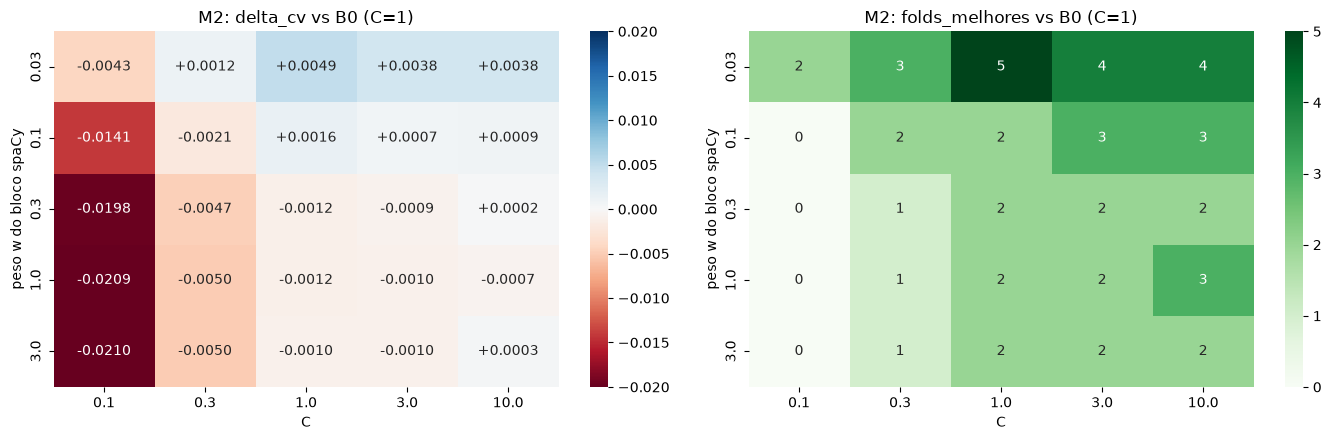

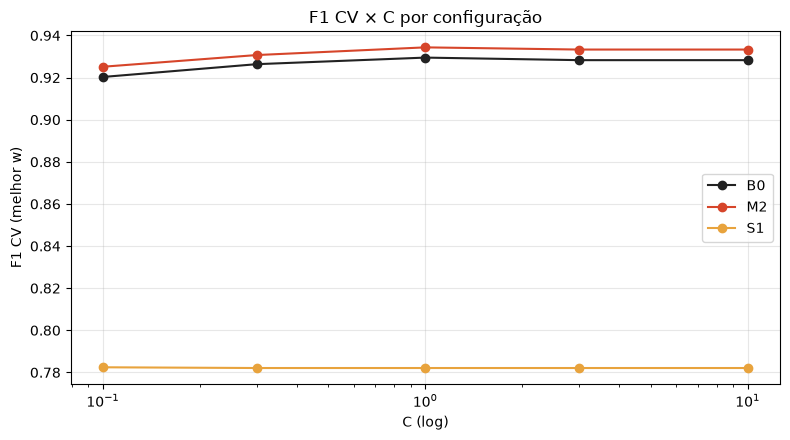

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, col, fmt in [(axes[0], "delta_cv", "+.4f"), (axes[1], "folds_melhores", "d")]:
    piv = res[res.config == "M2"].pivot(index="w_meta", columns="C", values=col)
    kw = dict(cmap="RdBu", center=0, vmin=-0.02, vmax=0.02) if col == "delta_cv" else dict(cmap="Greens", vmin=0, vmax=5)
    sns.heatmap(piv, annot=True, fmt=fmt, ax=ax, **kw)
    ax.set_title(f"M2: {col} vs B0 (C=1)")
    ax.set_xlabel("C"); ax.set_ylabel("peso w do bloco spaCy")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
for cfg, cor in zip(CONFIGS, ["#222222", "#d6452a", "#e8a33d"]):
    s = res[res.config == cfg].groupby("C")["f1_cv"].max()
    ax.plot(s.index, s.values, marker="o", label=cfg, color=cor)
ax.set_xscale("log"); ax.set_xlabel("C (log)"); ax.set_ylabel("F1 CV (melhor w)")
ax.set_title("F1 CV × C por configuração"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

**Conclusão:**
- **O bloco spaCy só ajuda com peso baixo.**
  - O melhor M2 é **C=1, w=0,03**: F1 CV **0,9344 ± 0,0103**, Δ **+0,0049** contra o B0, com **5/5 folds melhores** (desvio das diferenças 0,0026).
  - Com w ≥ 0,3 o Δ é ≤ 0 em quase todo C. Com C=0,1, qualquer peso piora (até −0,021), porque o bloco denso toma a margem e o modelo entra em underfitting.
- **O ganho é pequeno e frágil.**
  - Pelo critério do time ele não é empate (5/5 folds), mas é metade do limiar de 0,01.
  - Só uma célula do grid chega a 5/5; as vizinhas ficam em 2–4/5.
  - O ótimo está na borda do grid de w, e escolher o máximo entre 25 candidatos infla o número.
- **O gap quase não muda** (0,0656 contra 0,0705): o F1 de treino continua 1,0.
- **S1** (só spaCy, 24 features) chega a **0,7824**, com gap ≈ 0 por underfitting. Há sinal linguístico real, mas muito menor que o do texto.
- O B0 confirma o notebook 06: C=1 é o ótimo (0,9295), e C=3 e C=10 dão 0,9283.

## 7. Equivalência com o `Pipeline` real e χ² no bloco de texto

**Pergunta 1:** o motor por blocos dá os mesmos scores que um `Pipeline(ColumnTransformer(..., transformer_weights), LinearSVC)` passado ao `cross_validate`?

**Pergunta 2 (opcional do desenho):** no melhor M2, selecionar `k` ∈ {20.000; 50.000; all} n-gramas por χ² **só no bloco TF-IDF** muda alguma coisa?

In [14]:
CANDIDATOS_META = res[res.config == "M2"]
melhor_m = CANDIDATOS_META.loc[CANDIDATOS_META.f1_cv.idxmax()]
print(f"Melhor M2: C={melhor_m.C} w={melhor_m.w_meta} | F1 CV {melhor_m.f1_cv:.4f}")

def pipeline_real(cfg, C, w=1.0):
    txt, meta = CONFIGS[cfg]
    trans, pesos = [], {}
    if txt:
        trans += list(configs["word+char"])
    if meta:
        trans.append(("meta", meta_pipe(), BLOCOS_META[meta]))
        pesos["meta"] = w if txt else 1.0
    return Pipeline([("prep", ColumnTransformer(trans, transformer_weights=pesos or None)),
                     ("clf", clone(SVC_BASE).set_params(C=C))])

r = cross_validate(pipeline_real(melhor_m.config, melhor_m.C, melhor_m.w_meta), X_tr_full, y_tr,
                   cv=cv, scoring="f1_macro", n_jobs=2)
print("Pipeline real :", np.round(r["test_score"], 4), f"média {r['test_score'].mean():.4f}")
print("Motor por blocos:", np.round(melhor_m.folds, 4), f"média {melhor_m.f1_cv:.4f}")
print(f"Maior diferença por fold: {np.abs(r['test_score'] - melhor_m.folds).max():.5f}")

Melhor M2: C=1.0 w=0.03 | F1 CV 0.9344


Pipeline real : [0.934  0.9201 0.9523 0.9332 0.9323] média 0.9344
Motor por blocos: [0.934  0.9201 0.9523 0.9332 0.9323] média 0.9344
Maior diferença por fold: 0.00000


In [15]:
linhas_chi2 = [avaliar(melhor_m.config, melhor_m.C, melhor_m.w_meta, k=k) for k in [20000, 50000]]
res_chi2 = tabela(linhas_chi2)
pd.concat([res_chi2[COLS], CANDIDATOS_META.loc[[melhor_m.name], COLS]]).round(4)

,config,C,w_meta,k_chi2,n_feats,f1_treino,f1_cv,f1_cv_std,gap,delta_cv,delta_std,folds_melhores,fit_time_s
0,M2,1.0,0.03,20000,20024,0.9952,0.9358,0.0061,0.0595,0.0062,0.0076,3,9.6303
1,M2,1.0,0.03,50000,50024,0.9999,0.9397,0.0066,0.0601,0.0102,0.0054,5,10.6484
15,M2,1.0,0.03,all,114325,1.0000,0.9344,0.0103,0.0656,0.0049,0.0026,5,10.6308


**Conclusão:**
- **Equivalência:** o motor por blocos e o `Pipeline` real dão scores **idênticos** nos 5 folds (diferença máxima 0,00000). Os números da seção 6 valem para o pipeline que seria usado em produção.
- **χ² no texto do melhor M2:**
  - **k=50 mil** sobe para **0,9397 ± 0,0066** (Δ +0,0102 contra o B0, 5/5 folds) e reduz o gap para 0,060;
  - **k=20 mil** fica em 0,9358 (3/5 folds).
- **Ressalvas:**
  - No notebook 08, o mesmo χ² com k=50 mil **no B0** dava 0,9288 (empate). O ganho só aparece combinado com o spaCy e depois de duas rodadas de seleção (C/w e depois k), então é a estimativa mais otimista do notebook.
  - **Pela regra "melhor média CV", essa seria a configuração escolhida, mas a seção 8 avalia o M2 com k=all.** Ficou como pendência, sem avaliação no teste.

## 8. Avaliação final no teste interno (`X_te`, uma única vez)

**Regra de escolha (só CV):** o M2 avaliado é o de **melhor F1 CV** (seção 7). Ele é avaliado no teste junto com a base B0 (C=1). A recomendação final segue o critério pareado da CV: Δ < 0,01 sem 5/5 folds melhores é empate e, em empate, fica a mais simples (B0). O teste só confirma ou desmente; não escolhe nada.

Os modelos são reajustados no `X_tr` completo, com o `Pipeline` real.

Salvo: resultados_svm_meta_cv.csv


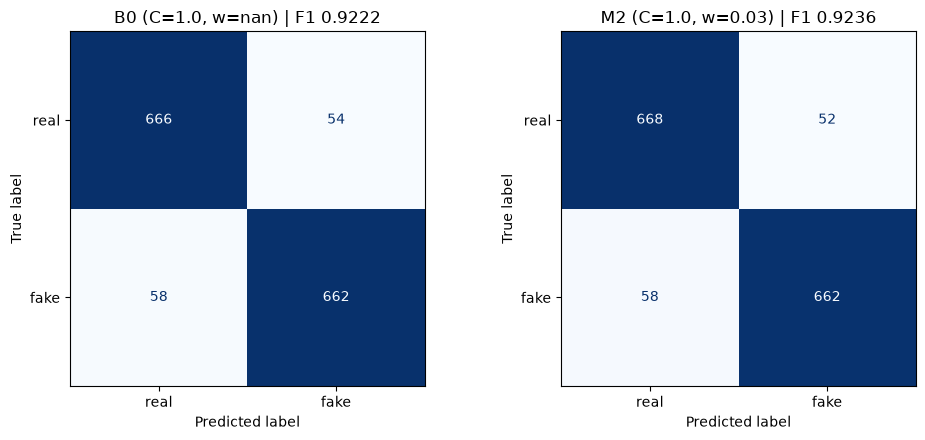

,conjunto,config,C,w_meta,n,f1_macro,roc_auc,pct_prev_fake,tn,fp,fn,tp,erro_real_como_fake,erro_fake_como_real
0,interno (Fake.br X_te),B0,1.0,NaN,1440,0.9222,0.9830,0.4972,666,54,58,662,0.0750,0.0806
1,interno (Fake.br X_te),M2,1.0,0.03,1440,0.9236,0.9846,0.4958,668,52,58,662,0.0722,0.0806


In [16]:
pd.concat([res, res_chi2]).round(6)[COLS].to_csv("../resultados/resultados_svm_meta_cv.csv", index=False)
print("Salvo: resultados_svm_meta_cv.csv")

def linha_teste(conjunto, cfg, C, w, y, pipe, X):
    score = pipe.decision_function(X)
    pred = (score > 0).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {"conjunto": conjunto, "config": cfg, "C": C, "w_meta": w, "n": len(y),
            "f1_macro": f1_score(y, pred, average="macro"), "roc_auc": roc_auc_score(y, score),
            "pct_prev_fake": pred.mean(), "tn": tn, "fp": fp, "fn": fn, "tp": tp,
            "erro_real_como_fake": fp / (tn + fp), "erro_fake_como_real": fn / (fn + tp)}, pred

escolhidos = {"B0": (1.0, np.nan), melhor_m.config: (melhor_m.C, melhor_m.w_meta)}
modelos_finais, linhas_teste = {}, []
fig, axes = plt.subplots(1, len(escolhidos), figsize=(5 * len(escolhidos), 4.5))
for ax, (cfg, (C, w)) in zip(np.atleast_1d(axes), escolhidos.items()):
    pipe = pipeline_real(cfg, C, 1.0 if np.isnan(w) else w).fit(X_tr_full, y_tr)
    modelos_finais[cfg] = pipe
    linha, pred = linha_teste("interno (Fake.br X_te)", cfg, C, w, y_te, pipe, X_te_full)
    linhas_teste.append(linha)
    ConfusionMatrixDisplay.from_predictions(y_te, pred, display_labels=["real", "fake"], cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{cfg} (C={C}, w={w}) | F1 {linha['f1_macro']:.4f}")
plt.tight_layout()
plt.show()
pd.DataFrame(linhas_teste).round(4)

**Conclusão:**
- **Teste interno:**
  - **B0:** F1 0,9222, AUC 0,9830.
  - **M2:** F1 0,9236, AUC 0,9846.
  - A diferença é de +0,0014 de F1 (2 falsos positivos a menos), bem dentro do erro padrão de ~±0,007 com 1.440 notícias.
- **A direção confirma a CV, mas o ganho é desprezível na prática.** Os erros ficam equilibrados entre as classes nos dois modelos (~7–8% para cada lado).

## 9. Teste externo: FakeRecogna

**Pergunta:** o bloco spaCy ajuda fora do domínio?

- A base de teste é montada como no notebook 07: títulos de `boatos.org` sem `#boato` contra o mesmo número de títulos reais (`random_state=42`), com a mesma `normalizar()`.
- B0, M2 e S1 são todos aplicáveis, porque o bloco spaCy é calculado a partir do próprio título.
- M2 e S1 usam o melhor (C, w) de cada um na CV, e B0 usa C=1. Nenhuma escolha é feita no externo.
- **Ressalva:** são títulos (~13 palavras) contra os 100 tokens do treino. Taxas em ~13 tokens são muito ruidosas, e títulos sem verbo ficam com NaN no modo verbal, imputado pela mediana do treino.

In [17]:
CSV = Path("../../data/FakeRecogna.csv")
if not CSV.exists():
    pd.read_csv("https://huggingface.co/datasets/recogna-nlp/FakeRecogna/resolve/main/FakeRecogna.csv").to_csv(CSV, index=False)

d = pd.read_csv(CSV)
d["dominio"] = d.URL.fillna("").str.extract(r"https?://(?:www\.)?([^/]+)")[0]
fake = d[(d.Classe == 0) & (d.dominio == "boatos.org")].copy()
fake["texto_trunc"] = fake.Titulo.str.replace(r"#boato", "", case=False, regex=True)
real = d[d.Classe == 1].sample(len(fake), random_state=42).copy()
real["texto_trunc"] = real.Titulo
ext = pd.concat([fake, real])
ext["texto_trunc"] = ext.texto_trunc.fillna("").map(normalizar)
ext = ext[ext.texto_trunc.str.len() > 0].reset_index(drop=True)
ext["label"] = (ext.Classe == 0).astype(int)

CACHE_EXT = Path("../../data/metadados_spacy_fakerecogna.parquet")
if CACHE_EXT.exists():
    feats_ext = pd.read_parquet(CACHE_EXT)
else:
    feats_ext = ms.extrair(ext["texto_trunc"], batch_size=64)
    feats_ext.to_parquet(CACHE_EXT)
assert len(feats_ext) == len(ext)
ext = ext.join(feats_ext[META_SPACY + ["n_tokens"]])

print(f"{len(ext):,} títulos ({ext.label.sum():,} fake / {(1 - ext.label).sum():,} real)")
print(f"Tokens spaCy por título: mediana {ext.n_tokens.median():.0f} (treino: {feats_tr.n_tokens.median():.0f})")
print(f"Títulos sem verbo (modo verbal imputado): {ext[META_SPACY].isna().any(axis=1).mean():.1%}")

4,968 títulos (2,484 fake / 2,484 real)
Tokens spaCy por título: mediana 13 (treino: 114)
Títulos sem verbo (modo verbal imputado): 2.4%


In [18]:
m2 = melhor_m
s1 = res[res.config == "S1"].sort_values("f1_cv").iloc[-1]
externos = {"B0": (1.0, np.nan), "M2": (m2.C, m2.w_meta), "S1": (s1.C, np.nan)}

linhas_ext = []
for cfg, (C, w) in externos.items():
    pipe = modelos_finais.get(cfg) if cfg in escolhidos and escolhidos[cfg][0] == C else None
    if pipe is None:
        pipe = pipeline_real(cfg, C, 1.0 if np.isnan(w) else w).fit(X_tr_full, y_tr)
    linha, _ = linha_teste("externo (FakeRecogna títulos)", cfg, C, w, ext["label"], pipe, ext)
    linhas_ext.append(linha)

teste = pd.DataFrame(linhas_teste + linhas_ext)
teste.round(6).to_csv("../resultados/resultados_svm_meta_teste.csv", index=False)
print("Salvo: resultados_svm_meta_teste.csv")
teste.round(4)

Salvo: resultados_svm_meta_teste.csv


,conjunto,config,C,w_meta,n,f1_macro,roc_auc,pct_prev_fake,tn,fp,fn,tp,erro_real_como_fake,erro_fake_como_real
0,interno (Fake.br X_te),B0,1.0,NaN,1440,0.9222,0.9830,0.4972,666,54,58,662,0.0750,0.0806
1,interno (Fake.br X_te),M2,1.0,0.03,1440,0.9236,0.9846,0.4958,668,52,58,662,0.0722,0.0806
2,externo (FakeRecogna títulos),B0,1.0,NaN,4968,0.6119,0.7072,0.7075,1046,1438,407,2077,0.5789,0.1638
3,externo (FakeRecogna títulos),M2,1.0,0.03,4968,0.6134,0.6622,0.5934,1300,1184,720,1764,0.4767,0.2899
4,externo (FakeRecogna títulos),S1,0.1,NaN,4968,0.5577,0.5844,0.5785,1197,1287,897,1587,0.5181,0.3611


**Conclusão: o bloco spaCy piora a ordenação fora do domínio.**

| | F1 externo | AUC externo | % previsto fake |
|---|---|---|---|
| B0 | 0,6119 | **0,7072** | 70,8% |
| M2 | 0,6134 | **0,6622** | 59,3% |
| S1 | 0,5577 | 0,5844 | 57,9% |

- O F1 fica igual, mas o **AUC cai 0,045**. O M2 só desloca o limiar (menos "fake"), sem ordenar melhor. O S1 fica perto do acaso.
- **Causa provável: deslocamento de distribuição.** Um título é uma sentença única de ~13 tokens (mediana 13 contra 114 no treino), então `taxa_sentencas` e `tam_medio_sentenca_sp` caem fora da faixa vista no treino. Mesmo com w=0,03, isso move a decisão.
- Isso é tanto uma limitação do teste (título contra corpo de texto) quanto um alerta para o app: as features spaCy dependem do formato do texto.
- O B0 dá 0,6119 contra 0,6122 do notebook 07 por causa da tolerância do solver primal; o AUC é idêntico.

## 10. Importância: coeficientes do bloco meta

**Pergunta:** o que o LinearSVC aprende no bloco meta?

Os coeficientes só são comparáveis entre si porque o bloco está padronizado. Mostramos o efeito por desvio padrão da feature (coeficiente × w), que não depende do peso escolhido. Positivo empurra para **fake** e negativo para **real**. Usamos o melhor M2 da CV, reajustado no `X_tr` completo.


M2 (C=1.0, w=0.03): 10 maiores |coef × w| (+ = fake)
tam_medio_sentenca_sp   -0.0853
taxa_sentencas           0.0808
pos_DET                  0.0720
pos_ADP                 -0.0478
pos_AUX                  0.0402
pos_CCONJ               -0.0382
pos_NOUN                -0.0364
pos_NUM                  0.0319
dep_nmod                -0.0270
dep_mark                -0.0246


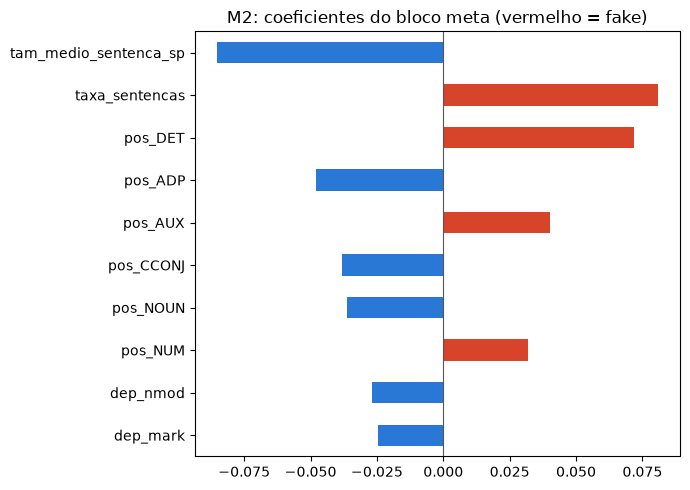

In [19]:
def coef_meta(cfg, C, w):
    pipe = pipeline_real(cfg, C, w).fit(X_tr_full, y_tr)
    nomes = pipe.named_steps["prep"].get_feature_names_out()
    coef = pd.Series(pipe.named_steps["clf"].coef_.ravel(), index=nomes)
    meta = coef[coef.index.str.startswith("meta__")] * w
    meta.index = meta.index.str.replace("meta__", "")
    return meta

para_mostrar = {"M2": (m2.C, m2.w_meta)}

fig, axes = plt.subplots(1, len(para_mostrar), figsize=(7 * len(para_mostrar), 5))
for ax, (cfg, (C, w)) in zip(np.atleast_1d(axes), para_mostrar.items()):
    meta = coef_meta(cfg, C, w)
    top = meta.reindex(meta.abs().sort_values(ascending=False).index[:10])
    print(f"\n{cfg} (C={C}, w={w}): 10 maiores |coef × w| (+ = fake)")
    print(top.round(4).to_string())
    top[::-1].plot.barh(ax=ax, color=["#d6452a" if v > 0 else "#2a78d6" for v in top[::-1]])
    ax.axvline(0, color="#555", lw=0.8)
    ax.set_title(f"{cfg}: coeficientes do bloco meta (vermelho = fake)")
plt.tight_layout()
plt.show()

**Conclusão:** os 10 maiores efeitos, por desvio padrão, são coerentes com o d de Cohen da seção 4. São pequenos frente aos n-gramas, já que w=0,03.
- **Puxam para real:** sentenças longas (`tam_medio_sentenca_sp` −0,085), ADP, NOUN, CCONJ, `nmod` e `mark`.
- **Puxam para fake:** muitas sentenças por token (`taxa_sentencas` +0,081), DET, AUX e NUM.
- O sinal dominante é **estrutura de sentença** (curtas contra longas e nominais). É justamente a feature que mais muda quando o texto é um título, o que explica a queda do AUC externo.

## 11. Resumo

Tabela-resumo B0 × M2 × S1 (melhor candidato de cada um, Δ pareado contra B0 com C=1):

In [20]:
resumo = melhores.loc[["B0", "M2", "S1"],
                      ["C", "w_meta", "f1_cv", "f1_cv_std", "gap", "delta_cv", "delta_std", "folds_melhores"]]
def veredito(r):
    if r.name == "B0":
        return "base"
    if r.delta_cv >= 0.01 or (r.delta_cv > 0 and r.folds_melhores == 5):
        return "ganho"
    if r.delta_cv <= -0.01 or (r.delta_cv < 0 and r.folds_melhores == 0):
        return "perda"
    return "empate"
resumo["veredito"] = resumo.apply(veredito, axis=1)
resumo.round(4)

,C,w_meta,f1_cv,f1_cv_std,gap,delta_cv,delta_std,folds_melhores,veredito
config,,,,,,,,,
B0,1.0,NaN,0.9295,0.0099,0.0705,0.0000,0.0000,0,base
M2,1.0,0.03,0.9344,0.0103,0.0656,0.0049,0.0026,5,ganho
S1,0.1,NaN,0.7824,0.0082,0.0028,-0.1471,0.0077,0,perda


As conclusões em texto estão em `METADADOS_SPACY.md`, escrito a partir dos outputs deste notebook.